# Experiment 3: what actually cuts, the hard floor or the robust z-score?

**Question.** The tiler places a boundary at a gap when either of two independent tests fires (`pipeline._build_groups`, in `cut_at`):

- **floor** (absolute): `d[gap] >= 1 - floor`. With `d = 1 - cos` and the default `floor = 0.6`, this is simply *cut when the window-to-window cosine similarity drops to 0.6 or below*. It is a fixed number on the embedder's cosine scale.
- **z-score** (relative): `_is_boundary`, a robust z-score `(d[k] - median) / MAD` above `threshold = 3.0`, measured against the local neighbourhood (`baseline_radius = 15`). It is scale-free: it reacts to how much a gap stands out from its surroundings, not to any absolute value.

The README foregrounds the relative z-score as the clever part and calls the design "generic ... nothing is calibrated to a particular document length, domain or writing style". But `floor = 0.6` *is* an absolute calibration, and it is tied to the cosine distribution of the default embedder (`Qwen3-Embedding-4B`), whose similarities are anisotropic and sit high. So the concern is: **on real text, does the hard floor do most of the cutting, leaving the robust-statistics machinery mostly redundant?**

This notebook measures it three ways: (1) a gap-level decomposition of which test fires where, on the real statute and on a clean synthetic passage for contrast; (2) an outcome-level run of the whole tiler with each mechanism turned off in turn; (3) a sensitivity sweep of the floor value. No assertions, just observation.

In [1]:
from pathlib import Path

import fitz
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.patches import Patch

from text_change_detector.shared.embedder import SentenceTransformerEmbedder
from text_change_detector.shared.models import Segment
from text_change_detector.tiling import pipeline
from text_change_detector.tiling.pipeline import tile
from text_change_detector.tiling.extraction.pdf import extract_pdf
from text_change_detector.tiling.extraction.shared import load_nlp

FLOOR = 0.6
RADIUS = 15
THRESHOLD = 3.0
WINDOW = 4
C_FLOOR = '#c0392b'
C_Z = '#e08a1e'
C_BOTH = '#7d3c98'
C_NONE = '#cbd5db'

/home/marek/repos/priv/text_change_detector/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def pick_device():
    if torch.cuda.is_available() and torch.cuda.mem_get_info()[0] > 9 * 1024 ** 3:
        return 'cuda'

    return 'cpu'


DEVICE = pick_device()
embedder = SentenceTransformerEmbedder(device=DEVICE, batch_size=8)

print('device:', DEVICE)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:  25%|██▌       | 100/398 [00:00<00:00, 995.16it/s]

Loading weights:  50%|█████     | 200/398 [00:00<00:00, 969.49it/s]

Loading weights:  75%|███████▍  | 297/398 [00:00<00:00, 940.06it/s]

Loading weights:  99%|█████████▉| 394/398 [00:00<00:00, 949.19it/s]

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 960.71it/s]

device: cuda


## Inputs: the real statute and a clean synthetic passage

The real input is the first 50 pages of the Polish Code of Civil Procedure (same extraction as notebook 2). The contrast input is the 40-sentence single-topic library passage from notebook 1: prose written so that adjacent facets are genuinely distinct, which is the friendly case the relative test was designed for. If the floor dominates even there, it dominates everywhere.

In [3]:
PDF = next(p for p in [Path('data/DU_2023_1550_KPC.pdf'),
                       Path('experiments/data/DU_2023_1550_KPC.pdf')] if p.exists())
PAGES = 50
src = fitz.open(PDF)
fragment = fitz.open()

fragment.insert_pdf(src, from_page=0, to_page=PAGES - 1)

nlp = load_nlp('pl_core_news_sm')
kpc_segments = extract_pdf(fragment, nlp)
kpc_sentences = [s.text for s in kpc_segments]
SYN_SENTENCES = [
    'The city library lends books to any resident who holds a valid membership card.',
    'A new member registers at the front desk by presenting a photo ID and proof of address.',
    'The librarian then issues a card that is valid for three years from the date of registration.',
    'Each member may borrow up to ten books at a time.',
    'The standard loan period for a book is twenty-one days.',
    'A member can check the due date printed on the receipt handed out at the counter.',
    'Borrowed books may be renewed twice if no other reader has reserved them.',
    'A renewal extends the loan by a further twenty-one days from the day it is granted.',
    "Members renew a book either at the desk or through the library's online catalogue.",
    'When a title is already on loan, a member may place a reservation on it.',
    'The system notifies the member by email as soon as a reserved book is returned.',
    'A reserved book is then held at the pickup shelf for seven days.',
    'If the member does not collect it within that week, the reservation is cancelled.',
    "Returning a book on time keeps the member's account in good standing.",
    'A book returned after its due date incurs a fine of twenty cents per day.',
    'The fine stops accruing once the outstanding balance reaches ten euros for a single title.',
    'Members can pay their fines at the desk or online through the member portal.',
    'An account with unpaid fines above five euros is blocked from further borrowing.',
    'The block is lifted automatically the moment the balance falls back below that limit.',
    'Books may be returned to the front desk during opening hours.',
    'Outside opening hours, members drop books into the return bin beside the main entrance.',
    'Staff empty the return bin every morning and check each book back into the system.',
    'A book is only counted as returned once staff have scanned it at the desk.',
    'Damaged books are set aside for the repair team to assess.',
    'A member who returns a badly damaged book may be charged its replacement cost.',
    'Lost books are billed at the replacement cost plus a small processing fee.',
    'Reference books and rare editions are marked as non-circulating and cannot be borrowed.',
    'These titles may only be consulted inside the reading room.',
    "Children under twelve borrow on a junior card linked to a parent's account.",
    'The junior card carries a lower borrowing limit of five books at a time.',
    'Audiobooks and DVDs follow the same loan period as printed books.',
    'However, DVDs may not be renewed and must be returned within the first loan period.',
    'Members can browse the full catalogue from home using their card number and a PIN.',
    'The online catalogue shows whether each copy is available, on loan, or reserved.',
    'A member who forgets their PIN can reset it by confirming their email address.',
    'The library sends a courtesy reminder three days before any book falls due.',
    'A second reminder follows on the morning after a book becomes overdue.',
    'Members who prefer paper notices can opt out of email reminders at the desk.',
    'All borrowing history is kept private and is visible only to the member and staff.',
    'Members may ask staff to erase their past borrowing records at any time.',
]
syn_segments = [Segment(text=s) for s in SYN_SENTENCES]

print('KPC segments      :', len(kpc_segments))
print('synthetic segments:', len(syn_segments))

KPC segments      : 1001
synthetic segments: 40


## The decomposition

`decompose` rebuilds exactly the two conditions inside `cut_at`, on the same signal `d` the tiler uses (`_step_dissimilarities`, window 4). For every gap it records whether the **floor** would cut, whether the **z-score** would cut, or both. This is the candidate-gap view: it is the precise arithmetic of the two tests, before window growth, `force_grow` and dedup decide which candidates become realized unit edges. The outcome view comes later, by running the whole tiler.

In [4]:
def decompose(sentences, floor=FLOOR, radius=RADIUS, threshold=THRESHOLD, window=WINDOW):
    d = pipeline._step_dissimilarities(sentences, embedder, window)
    n = len(d)
    floor_cut = np.array([d[i] >= 1.0 - floor for i in range(n)])
    z_cut = np.array([pipeline._is_boundary(d, i, radius, threshold) for i in range(n)])
    union = floor_cut | z_cut

    return {
        'd': d,
        'floor': floor_cut,
        'z': z_cut,
        'union': union,
        'floor_only': floor_cut & ~z_cut,
        'z_only': z_cut & ~floor_cut,
        'both': floor_cut & z_cut,
    }


def summarize(name, r):
    tot = int(r['union'].sum())
    nf = int(r['floor'].sum())
    nz = int(r['z'].sum())
    nb = int(r['both'].sum())

    print(f'{name}')
    print(f'  gaps                : {len(r["d"])}')
    print(f'  cuts (union)        : {tot}')
    print(f'  floor cuts          : {nf}   ({nf / max(tot, 1):.0%} of all cuts)')
    print(f'  z-score cuts        : {nz}   ({nz / max(tot, 1):.0%} of all cuts)')
    print(f'  both agree          : {nb}')
    print(f'  floor only          : {int(r["floor_only"].sum())}')
    print(f'  z-score only (extra): {int(r["z_only"].sum())}   (boundaries the floor alone would miss)')
    print(f'  floor recall of union: {nf / max(tot, 1):.0%}')

    return {'gaps': len(r['d']), 'cuts': tot, 'floor': nf, 'z': nz,
            'both': nb, 'floor_only': int(r['floor_only'].sum()), 'z_only': int(r['z_only'].sum())}

## 1. Gap-level decomposition on the real statute (KPC)

In [5]:
kpc = decompose(kpc_sentences)
kpc_stats = summarize('KPC, first 50 pages', kpc)

KPC, first 50 pages
  gaps                : 1000
  cuts (union)        : 292
  floor cuts          : 292   (100% of all cuts)
  z-score cuts        : 16   (5% of all cuts)
  both agree          : 16
  floor only          : 276
  z-score only (extra): 0   (boundaries the floor alone would miss)
  floor recall of union: 100%


The plot: left, the distribution of the similarity signal `1 - d` with the floor line at 0.6, to see how much of the mass the floor sits inside (the anisotropy check); middle, the per-gap dissimilarity coloured by which test fires; right, the counts.

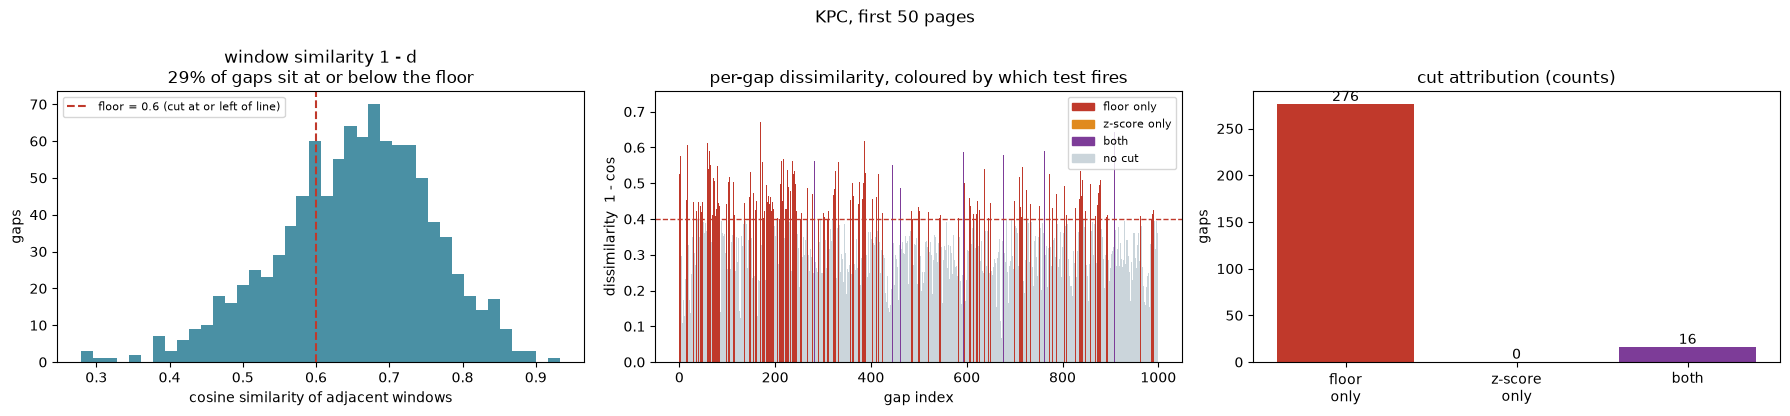

In [6]:
def category_colors(r):
    out = []

    for i in range(len(r['d'])):
        if r['both'][i]:
            out.append(C_BOTH)
        elif r['floor_only'][i]:
            out.append(C_FLOOR)
        elif r['z_only'][i]:
            out.append(C_Z)
        else:
            out.append(C_NONE)

    return out


def plot_decomp(r, title):
    d = r['d']
    sim = 1.0 - d
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.2))

    axes[0].hist(sim, bins=40, color='#4a90a4')
    axes[0].axvline(FLOOR, color=C_FLOOR, linestyle='--', linewidth=1.5,
                    label=f'floor = {FLOOR} (cut at or left of line)')

    below = float((sim <= FLOOR).mean())

    axes[0].set_title(f'window similarity 1 - d\n{below:.0%} of gaps sit at or below the floor')
    axes[0].set_xlabel('cosine similarity of adjacent windows')
    axes[0].set_ylabel('gaps')
    axes[0].legend(fontsize=8)
    axes[1].bar(range(len(d)), d, width=1.0, color=category_colors(r))
    axes[1].axhline(1.0 - FLOOR, color=C_FLOOR, linestyle='--', linewidth=1)
    axes[1].set_title('per-gap dissimilarity, coloured by which test fires')
    axes[1].set_xlabel('gap index')
    axes[1].set_ylabel('dissimilarity  1 - cos')
    axes[1].legend(handles=[Patch(color=C_FLOOR, label='floor only'),
                            Patch(color=C_Z, label='z-score only'),
                            Patch(color=C_BOTH, label='both'),
                            Patch(color=C_NONE, label='no cut')], fontsize=8)

    cats = ['floor\nonly', 'z-score\nonly', 'both']
    vals = [int(r['floor_only'].sum()), int(r['z_only'].sum()), int(r['both'].sum())]

    axes[2].bar(cats, vals, color=[C_FLOOR, C_Z, C_BOTH])

    for i, v in enumerate(vals):
        axes[2].text(i, v, str(v), ha='center', va='bottom')

    axes[2].set_title('cut attribution (counts)')
    axes[2].set_ylabel('gaps')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_decomp(kpc, 'KPC, first 50 pages')

## 2. The same on the clean synthetic passage, and side by side

Synthetic library passage
  gaps                : 39
  cuts (union)        : 11
  floor cuts          : 11   (100% of all cuts)
  z-score cuts        : 0   (0% of all cuts)
  both agree          : 0
  floor only          : 11
  z-score only (extra): 0   (boundaries the floor alone would miss)
  floor recall of union: 100%


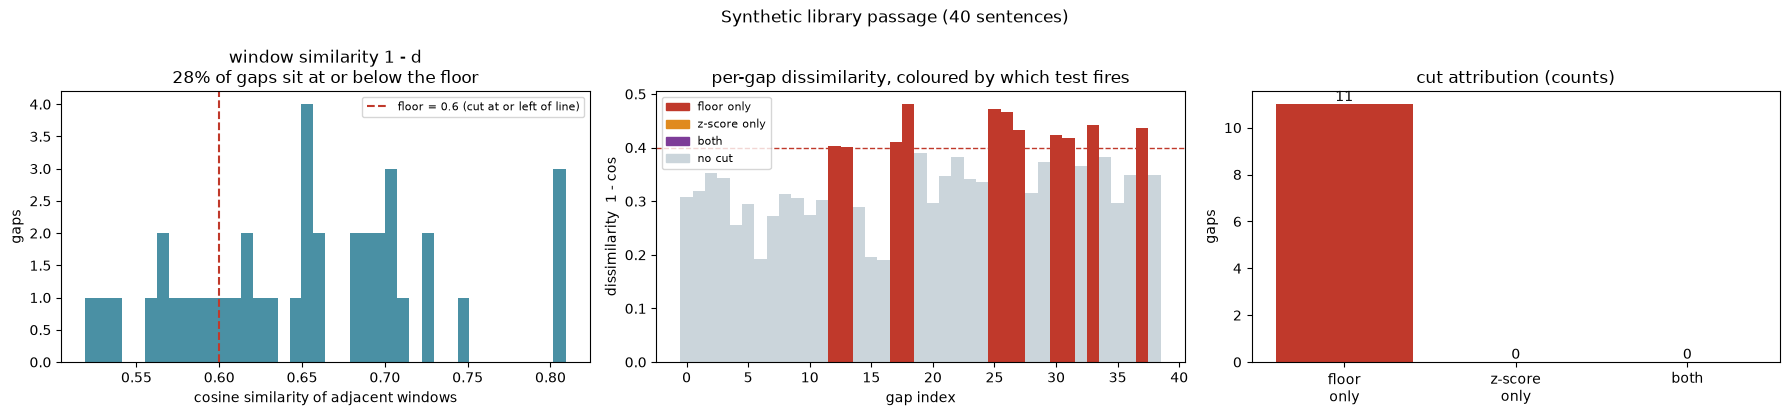

In [7]:
syn = decompose(SYN_SENTENCES)
syn_stats = summarize('Synthetic library passage', syn)

plot_decomp(syn, 'Synthetic library passage (40 sentences)')

In [8]:
def row(name, s):
    return (f'{name:24s} {s["gaps"]:6d} {s["cuts"]:6d} {s["floor"]:7d} {s["z"]:8d} '
            f'{s["both"]:6d} {s["floor_only"]:11d} {s["z_only"]:9d} '
            f'{s["floor"] / max(s["cuts"], 1):9.0%} {s["z_only"] / max(s["cuts"], 1):8.0%}')


hdr = (f'{"document":24s} {"gaps":>6s} {"cuts":>6s} {"floor":>7s} {"z-score":>8s} '
       f'{"both":>6s} {"floor_only":>11s} {"z_only":>9s} {"floor%cut":>9s} {"zextra%":>8s}')

print(hdr)
print('-' * len(hdr))
print(row('KPC (50 pages)', kpc_stats))
print(row('synthetic (clean)', syn_stats))

document                   gaps   cuts   floor  z-score   both  floor_only    z_only floor%cut  zextra%
-------------------------------------------------------------------------------------------------------
KPC (50 pages)             1000    292     292       16     16         276         0      100%       0%
synthetic (clean)            39     11      11        0      0          11         0      100%       0%


## 3. Outcome level: turn each mechanism off and re-tile

The gap view above is candidate cuts. Now the real end-to-end effect on the KPC statute: run `tile()` four ways and compare the number of semantic units and communities.

- **full**: both tests on (`floor = 0.6`, `threshold = 3.0`), the shipped default.
- **floor only**: z-score disabled (`threshold = inf`, so `_is_boundary` never fires).
- **z-score only**: floor disabled (`floor = -9`, so `1 - floor = 10` and `d` never reaches it).
- **neither**: no cutting test fires, so every window grows to `group_max_len`; the floor of how many units the growth-and-dedup alone yields.

If *floor only* lands close to *full* while *z-score only* sits far below it, the floor is carrying the segmentation.

In [9]:
def tile_counts(**kw):
    r = tile(kpc_segments, embedder=embedder, **kw)
    units = sum(len(c.units) for c in r.communities)

    return units, len(r.communities)


configs = {
    'full (0.6 / 3.0)': {},
    'floor only': {'threshold': float('inf')},
    'z-score only': {'floor': -9.0},
    'neither': {'floor': -9.0, 'threshold': float('inf')},
}
outcome = {}

for name, kw in configs.items():
    outcome[name] = tile_counts(**kw)

    print(f'{name:20s} units={outcome[name][0]:4d}  communities={outcome[name][1]:3d}')

full (0.6 / 3.0)     units= 347  communities= 11


floor only           units= 347  communities= 11


z-score only         units= 249  communities= 11


neither              units= 250  communities= 11


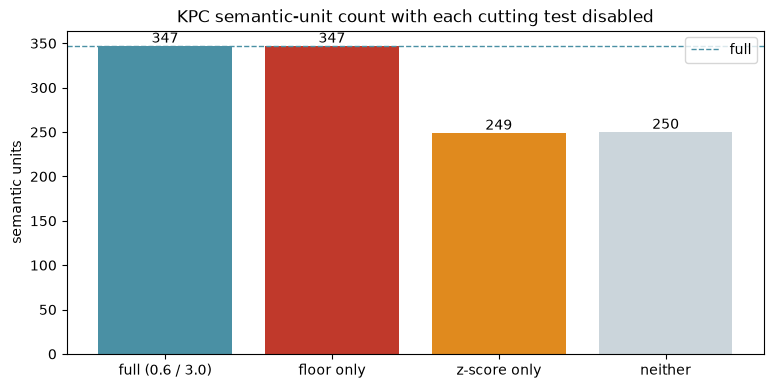

In [10]:
names = list(outcome)
units = [outcome[n][0] for n in names]
full_units = outcome['full (0.6 / 3.0)'][0]
fig, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.bar(names, units, color=['#4a90a4', C_FLOOR, C_Z, C_NONE])

ax.axhline(full_units, color='#4a90a4', linestyle='--', linewidth=1, label='full')

for b, v in zip(bars, units):
    ax.text(b.get_x() + b.get_width() / 2, v, str(v), ha='center', va='bottom')

ax.set_ylabel('semantic units')
ax.set_title('KPC semantic-unit count with each cutting test disabled')
ax.legend()
plt.show()

## 4. Sensitivity: how the floor value moves the cuts

Sweeping `floor` over the candidate cuts (free, no re-embedding, computed on the KPC signal). The floor line is how many gaps the floor alone would cut; the z-score line is constant because it does not depend on `floor`. Where the two cross tells you whether 0.6 sits on a plateau or on a slope, and how much of the segmentation the exact value of 0.6 is responsible for.

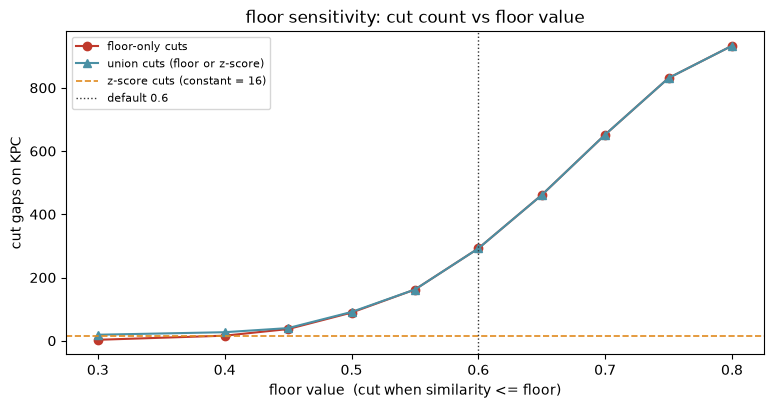

floors     : [0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
floor cuts : [3, 16, 37, 89, 162, 292, 461, 652, 831, 933]
union cuts : [19, 27, 40, 91, 162, 292, 461, 652, 831, 933]
z-score cuts (constant): 16


In [11]:
d_kpc = kpc['d']
z_kpc = kpc['z']
n_z = int(z_kpc.sum())
floors = [0.30, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
floor_counts = []
union_counts = []

for f in floors:
    fc = d_kpc >= 1.0 - f

    floor_counts.append(int(fc.sum()))
    union_counts.append(int((fc | z_kpc).sum()))

fig, ax = plt.subplots(figsize=(9, 4.2))

ax.plot(floors, floor_counts, marker='o', color=C_FLOOR, label='floor-only cuts')
ax.plot(floors, union_counts, marker='^', color='#4a90a4', label='union cuts (floor or z-score)')
ax.axhline(n_z, color=C_Z, linestyle='--', linewidth=1.2, label=f'z-score cuts (constant = {n_z})')
ax.axvline(FLOOR, color='#333333', linestyle=':', linewidth=1, label='default 0.6')
ax.set_xlabel('floor value  (cut when similarity <= floor)')
ax.set_ylabel('cut gaps on KPC')
ax.set_title('floor sensitivity: cut count vs floor value')
ax.legend(fontsize=8)
plt.show()

print('floors     :', floors)
print('floor cuts :', floor_counts)
print('union cuts :', union_counts)
print('z-score cuts (constant):', n_z)

## Observations

**Verdict. On this document the absolute floor does 100% of the cutting, and the robust z-score is entirely redundant.** The concern about the `0.6` magic constant is confirmed, and more sharply than expected: the median+MAD machinery the README foregrounds as the adaptive, embedder-agnostic part contributes nothing here.

**Gap level (KPC, first 50 pages, 1000 gaps).** Of 292 boundary-triggering gaps, the floor fires on all **292 (100%)** and the z-score on **16 (5%)**. Every one of those 16 is also a floor cut (`both = 16`), so the z-score adds **0** boundaries the floor would miss. The floor's recall of the full cut set is 100%: delete the z-score test and not a single boundary moves.

**Even on the clean synthetic passage** (40 sentences, adjacent facets deliberately distinct, the friendly case the relative test was built for) the z-score **never fires once** (0 of 11 cuts). It is not that legal text is uniquely hostile to it; the test just does not trigger at `threshold = 3.0` against a `baseline_radius = 15` window on this embedder's signal.

**Outcome level (whole tiler on KPC).** Turning each mechanism off, one at a time:

| config | units | vs full |
|---|---|---|
| full (`0.6` / `3.0`) | 347 | baseline |
| floor only (z-score off) | **347** | identical |
| z-score only (floor off) | 249 | collapses |
| neither (no cutting) | 250 | collapses |

The floor alone reproduces the shipped segmentation **exactly, unit for unit (347 = 347)**. The z-score alone (249) is indistinguishable from disabling all cutting (250): the difference of one unit is dedup/window-growth noise, not signal. So the robust-statistics stage, in isolation, segments the statute no better than not segmenting it at all.

**Sensitivity.** The floor sits on a **steep slope, not a plateau**: floor-only cuts go 89 -> 162 -> 292 -> 461 -> 652 as the value moves 0.50 -> 0.55 -> 0.60 -> 0.65 -> 0.70. Nudging the constant by 0.05 changes the cut count by 40-60%, so segmentation granularity is governed almost entirely by that one hardcoded number. The z-score line is flat at 16, and the floor overtakes it by around floor = 0.40: for any floor at or above ~0.4, the floor alone cuts more than the entire z-score does.

**So what.**
- The README's framing ("the boundary test is relative ... nothing is calibrated to a particular document length, domain or writing style") does not hold in practice. The operative test is the absolute `0.6`, a raw constant on `Qwen3-Embedding-4B`'s cosine scale. Swapping the embedder (which the README invites) shifts that whole distribution and silently rescales how aggressively `0.6` cuts, and there is no scale-free z-score underneath actually doing work to fall back on.
- The regime where the z-score would earn its place is the mirror image of this one: a document whose window similarities rarely fall to 0.6, so the floor stays silent and only a local spike could cut. That regime does not occur here (the floor already fires on 29% of gaps), so the adaptive test never gets to matter. Worth testing on a document with a higher, flatter similarity profile before concluding the z-score is dead weight in general, but on realistic messy text with this embedder it is.
- Practical options: (a) correct the README to name the floor as the primary mechanism and the z-score as a rare supplement; (b) make the floor embedder-relative, e.g. a percentile of the observed dissimilarity distribution instead of a raw 0.6, so it is not silently recalibrated by an embedder swap; or (c) rerun this decomposition whenever the embedder or `threshold` changes, since which mechanism dominates is a property of the pair, not a constant of the design.

In [12]:
embedder.close()